--- Running Unified Object-Oriented Pipeline (Horizon=3) ---

Processing Region: Lower Fraser Valley ...
  -> Training 3_LightGBM_Wildfire...
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.05 (F2 Score: 0.000)


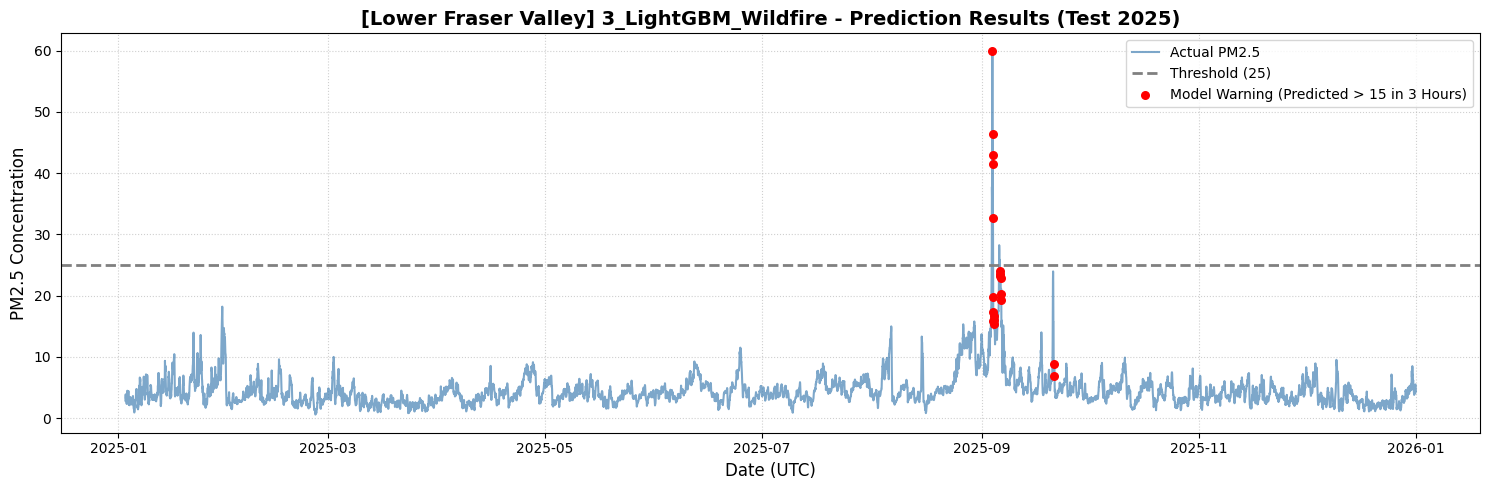

  -> Training 9_LSTM_AE_Wildfire...
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.05 (F2 Score: 0.000)


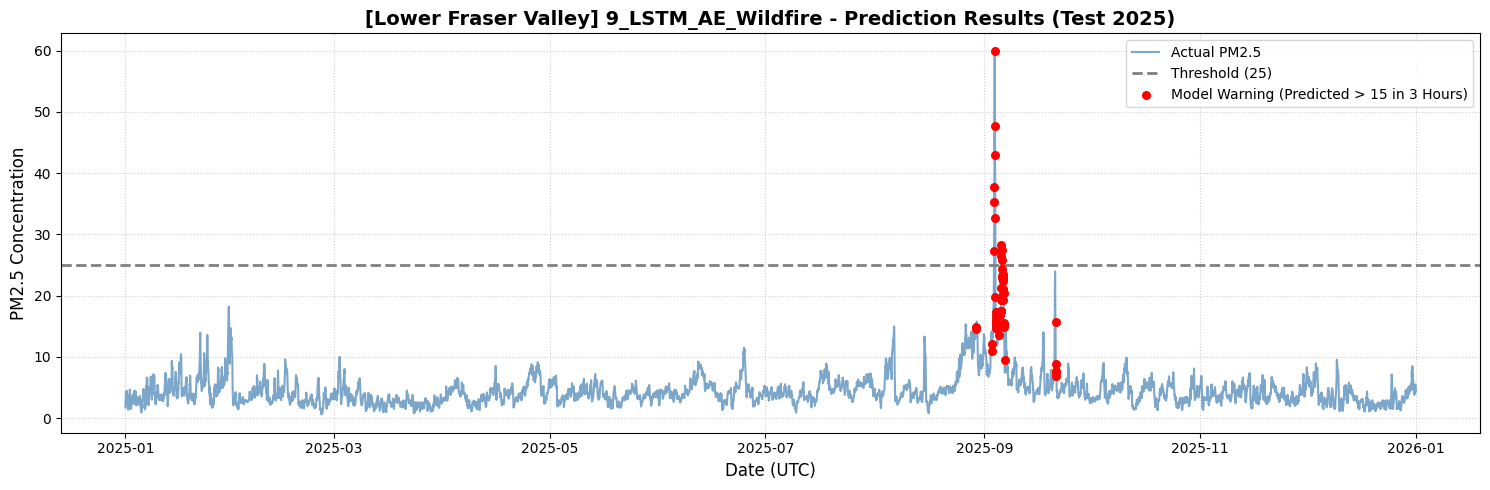


Processing Region: Southern Interior ...
  -> Training 3_LightGBM_Wildfire...
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.40 (F2 Score: 0.460)


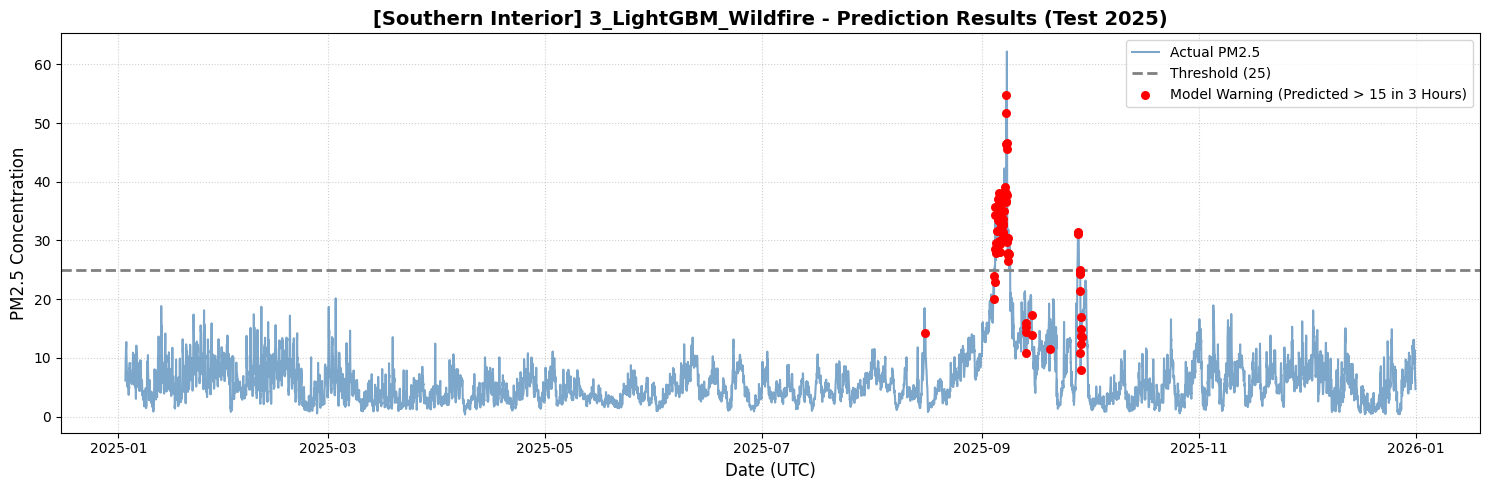

  -> Training 9_LSTM_AE_Wildfire...
      [Tuning] Optimizing Threshold for High Recall (F2-Score)...
      [Tuning] Selected Threshold: 0.85 (F2 Score: 0.607)


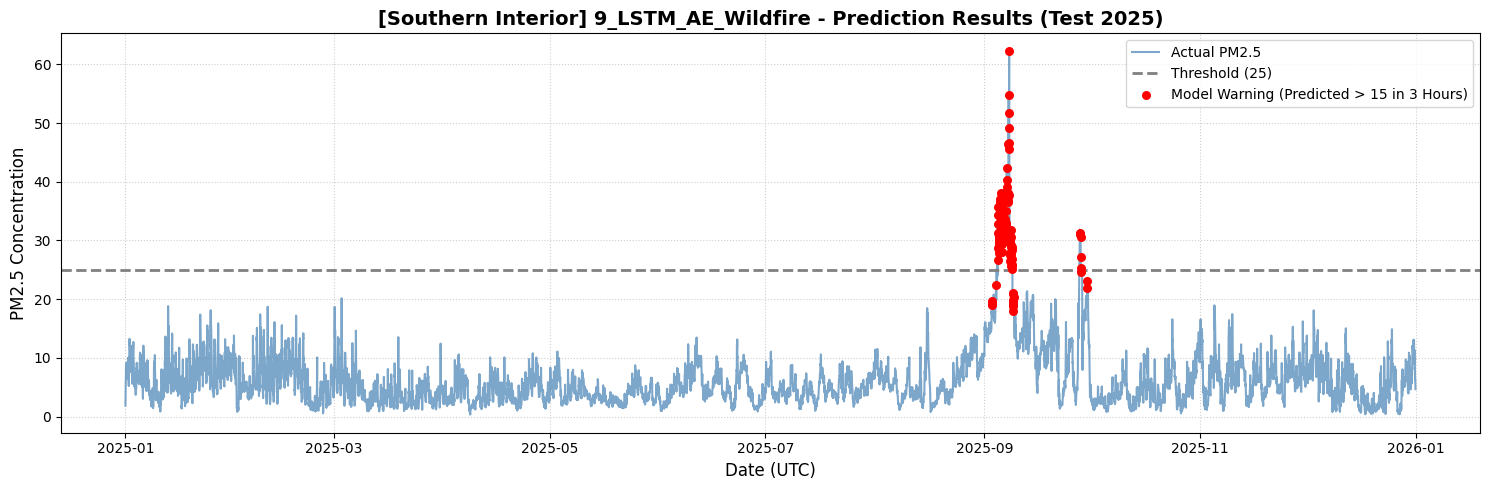


=== Final Classification Report ===


Probability_Threshold    Recall  \
Region_Name         Model_Type                                             
Lower Fraser Valley 3_LightGBM_Wildfire                   0.05  0.384615   
                    9_LSTM_AE_Wildfire                    0.05  0.846154   
Southern Interior   3_LightGBM_Wildfire                   0.40  0.586207   
                    9_LSTM_AE_Wildfire                    0.85  0.905172   

                                         Precision  Accuracy        F1  
Region_Name         Model_Type                                          
Lower Fraser Valley 3_LightGBM_Wildfire   0.263158  0.997475  0.312500  
                    9_LSTM_AE_Wildfire    0.207547  0.994977  0.333333  
Southern Interior   3_LightGBM_Wildfire   0.747253  0.991850  0.657005  
                    9_LSTM_AE_Wildfire    0.875000  0.997032  0.889831

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
import warnings

# Suppress warnings to keep the console output clean during execution
warnings.filterwarnings('ignore')

# Set up project directory paths dynamically to ensure cross-platform compatibility
current_dir = Path.cwd()
models_dir = current_dir / 'Models'

# Append the Models directory to the system path so custom modules can be imported
if str(models_dir) not in sys.path:
    sys.path.append(str(models_dir))

# Import constants and custom model classes
from Models.base_model import TARGET_COL, EXCEEDANCE_THRESHOLD, WILDFIRE_COLUMNS
from Models.lightboost import LightGBMModel         
from Models.LSTM_AE_model import AutoencoderLSTMModel 

if __name__ == "__main__":
    # Define the path to the input dataset relative to the current working directory
    PROJECT_DIRECTORY = Path.cwd().parents[0]
    dataset_file_path = PROJECT_DIRECTORY / "Dataset" / "Outputs" / "CS2_model_input.csv"
    
    # Load the dataset and ensure the datetime column is properly parsed
    raw_input_dataframe = pd.read_csv(dataset_file_path)
    raw_input_dataframe['Datetime_UTC'] = pd.to_datetime(raw_input_dataframe['Datetime_UTC'])
    
    # Identify all unique regions (zones) available in the dataset
    available_regions_list = raw_input_dataframe['Zone'].unique()
    all_results = []

    print("--- Running Unified Object-Oriented Pipeline (Horizon=3) ---")

    # Iterate through each region to train and evaluate models locally
    for region_name in available_regions_list:
        print(f"\nProcessing Region: {region_name} ...")
        
        # Isolate data for the current region and set the datetime as the index
        regional_df = raw_input_dataframe[raw_input_dataframe['Zone'] == region_name].copy()
        regional_df = regional_df.set_index('Datetime_UTC').sort_index()
        
        # Strip timezone information if it exists to avoid conflicts during modeling
        if regional_df.index.tz is not None:
            regional_df.index = regional_df.index.tz_localize(None)
            
        # Perform chronological train/validation/test splits based on the year
        train_data = regional_df[regional_df.index.year <= 2023].copy()
        val_data = regional_df[regional_df.index.year == 2024].copy()
        test_data = regional_df[regional_df.index.year == 2025].copy()
        
        # Skip regions that do not have enough training data points
        if len(train_data) < 200: 
            continue

        # Define the dictionary of candidate models to evaluate. 
        # You can easily toggle models on/off by commenting them out here.
        models_to_run = {
            "3_LightGBM_Wildfire": LightGBMModel(candidate_features=WILDFIRE_COLUMNS),
            "9_LSTM_AE_Wildfire": AutoencoderLSTMModel(candidate_features=WILDFIRE_COLUMNS),
        }

        # Train and evaluate each active model for the current region
        for model_name, model in models_to_run.items():
            print(f"  -> Training {model_name}...")
        

            model.fit(train_data)
            
            # Post-training: Standardize the decision threshold across all models.
            # We use the 2024 validation data to find the optimal probability threshold 
            # before making predictions on the unseen test set.
            model.tune_threshold(val_data)
            
            # Generate predictions on the 2025 test set
            test_preds = model.predict(test_data)
            processed_test = model.preprocess(test_data)
            
            # Convert actual continuous PM2.5 values into binary exceedance labels
            actuals = (processed_test[TARGET_COL] > EXCEEDANCE_THRESHOLD).astype(int)
            
            # Calculate classification metrics and store the results
            all_results.append({
                "Region_Name": region_name,
                "Model_Type": model_name,
                "Probability_Threshold": round(model.alert_probability_threshold, 2),
                "Recall": float(recall_score(actuals, test_preds, zero_division=0)),
                "Precision": float(precision_score(actuals, test_preds, zero_division=0)),
                "Accuracy": float(accuracy_score(actuals, test_preds)),
                "F1": float(f1_score(actuals, test_preds, zero_division=0))
            })

            # Visualize the prediction results against the actual PM2.5 values
            plt.figure(figsize=(15, 5))
            test_dates = processed_test.index
            actual_pm25 = processed_test[TARGET_COL].values
            
            # Plot the actual continuous target values
            plt.plot(test_dates, actual_pm25, label='Actual PM2.5', color='steelblue', alpha=0.7, linewidth=1.5)
            
            # Plot the regulatory exceedance threshold line
            plt.axhline(EXCEEDANCE_THRESHOLD, color='gray', linestyle='--', linewidth=2, label=f'Threshold ({EXCEEDANCE_THRESHOLD})')
            
            # Highlight the specific timestamps where the model issued a warning
            predicted_alert_indices = np.where(test_preds == 1)[0]
            plt.scatter(
                test_dates[predicted_alert_indices], actual_pm25[predicted_alert_indices], 
                color='red', s=30, zorder=5, label='Model Warning (Predicted > 15 in 3 Hours)'
            )
            
            # Format and display the plot
            plt.title(f'[{region_name}] {model_name} - Prediction Results (Test 2025)', fontsize=14, fontweight='bold')
            plt.xlabel('Date (UTC)', fontsize=12)
            plt.ylabel('PM2.5 Concentration', fontsize=12)
            plt.legend(loc='upper right')
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tight_layout()
            plt.show()

    # Output the final aggregated performance report
    print("\n=== Final Classification Report ===")
    results_df = pd.DataFrame(all_results)
    if not results_df.empty:
        # Organize the final DataFrame by Region and Model for easier reading
        results_df = results_df.set_index(["Region_Name", "Model_Type"]).sort_index()
        try:
            display(results_df) 
        except NameError:
            print(results_df) 
    else:
        print("No results generated.")